# Tibetan Research SDK Starter

This notebook demonstrates modular testing in a researcher workflow: segmentation, embeddings, and pairwise top-k retrieval.

In [1]:
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "tibetan_pipeline").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not find project root containing tibetan_pipeline/ and requirements.txt")

project_root = find_project_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from tibetan_pipeline import TibetanResearchSDK
print(f"project_root={project_root}")


/opt/homebrew/Caskroom/miniconda/base/envs/embedding-tibetan-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project_root=/Users/ten-jampa/Documents/personal_projects/embedding-model-for-tibetan-pairwise


In [2]:
sdk = TibetanResearchSDK(
    engine="botok_ours",
    source_format="unicode",
    model_id="buddhist-nlp/gemma-2-mitra-e",
    device="cpu",
    batch_size=1,
)

In [3]:
text_a = "བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད། ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ། མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།"
text_b = "སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད། དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད། སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།"
seg_a = sdk.segment_text(text_a)
seg_a.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,66,བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉི...
1,1,66,136,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...
2,2,136,192,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...
3,3,192,251,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...


In [5]:
for segment in seg_a.segments:
    print(segment)


བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད།
ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ།
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད།
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།


In [6]:
seg_b = sdk.segment_text(text_b)    
seg_b.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,70,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...
1,1,70,147,དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་...
2,2,147,223,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
3,3,223,284,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...


In [7]:
for segment in seg_b.segments:
    print(segment)


སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད།
དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད།
སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས།
དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།


In [8]:
embedding_view = sdk.embed_sentences(seg_a.segments)
embedding_view.to_dataframe().head()


The following generation flags are not valid and may be ignored: ['cache_implementation']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 464/464 [00:00<00:00, 1964.90it/s, Materializing param=model.norm.weight]                                


,sentence_index,sentence_text,vector_norm
0,0,བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉི...,1.0
1,1,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...,1.0
2,2,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,1.0
3,3,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,1.0


In [9]:
embedding_view_a = embedding_view

In [10]:
embedding_view_b = sdk.embed_sentences(seg_b.segments)
embedding_view_b.to_dataframe().head()

Loading weights: 100%|██████████| 464/464 [00:00<00:00, 1846.18it/s, Materializing param=model.norm.weight]                                


,sentence_index,sentence_text,vector_norm
0,0,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...,1.0
1,1,དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་...,1.0
2,2,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...,1.0
3,3,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...,1.0


In [11]:
from tibetan_pipeline.sdk import cosine_similarity_matrix, global_top_k_matches, PairwiseView

In [12]:
## custom code to do the pairwise calculation if the embeddings have already been calculated
# The error occurs because global_top_k_matches() does not accept 'top_k' as a keyword argument.
# Let's inspect its signature and call it with correct arguments. 
# If the correct argument is positional, pass it as such, not as a keyword.

# For most cosine similarity ranking utilities, the order may be:
# global_top_k_matches(matrix, sentences_a, sentences_b, k)
# Adjust accordingly (remove top_k=).

def _pairwise_from_embeddings(self, other, top_k: int = 5) -> PairwiseView:
    matrix = cosine_similarity_matrix(self.embeddings, other.embeddings)
    # Correction: pass top_k as a positional argument, not keyword, if expected so
    matches = global_top_k_matches(matrix, self.sentences, other.sentences, top_k)
    return PairwiseView(
        model_id=self.model_id,
        device=self.device,
        segments_a=self.sentences,
        segments_b=other.sentences,
        similarity_matrix=matrix,
        matches=matches,
    )

pairwise_view = _pairwise_from_embeddings(embedding_view_a, embedding_view_b)

pairwise_view

PairwiseView(model_id='buddhist-nlp/gemma-2-mitra-e', device='cpu', segments_a=['བོད་ཀྱི་རི་ཁྲོད་ན་རླུང་གི་སྒྲ་དང་ཆུ་ཡི་སྒྲ་གཉིས་མཉམ་དུ་ཐོས་པ་ཡོད།', 'ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ།', 'མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད།', 'རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན།'], segments_b=['སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད།', 'དགེ་རྒན་ཚོས་སློབ་མ་རྣམས་ལ་དྲི་བ་འདྲི་བ་དང་གསལ་བཤད་བྱས་ཏེ་རིག་པ་འཕེལ་བར་བྱེད།', 'སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས།', 'དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན།'], similarity_matrix=array([[0.3918082 , 0.30438712, 0.36354983, 0.33653054],
       [0.4211165 , 0.36429438, 0.37308785, 0.47688946],
       [0.43946594, 0.35884088, 0.47102752, 0.4152441 ],
       [0.37153065, 0.37198415, 0.42630604, 0.42282867]], dtype=float32), matches=[PairMatch(rank=1, score=0.4768894612789154, i=1, j=3, sentence_a='ཉི་མ་ཤར

In [13]:
pairwise_view.topk_dataframe()

,rank,score,i,j,sentence_a,sentence_b
0,1,0.476889,1,3,ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པ...,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...
1,2,0.471028,2,2,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
2,3,0.439466,2,0,མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོ...,སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གས...
3,4,0.426306,3,2,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས...
4,5,0.422829,3,3,རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ...,དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ...


In [14]:
for row in pairwise_view.topk_dataframe().itertuples():
    print(f'{row.sentence_a} -> {row.sentence_b} : {row.score}')
    

ཉི་མ་ཤར་བའི་དུས་སུ་རི་རྩེ་དང་གངས་རི་དག་ལ་གསལ་པོར་འོད་འཕྲོ་བ་མཐོང་ཐུབ། -> དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན། : 0.4768894612789154
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། -> སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། : 0.47102752327919006
མི་ཚོས་ས་ཆ་དེར་ཞི་བའི་སེམས་དང་དགའ་བ་ཆེན་པོ་མྱོང་གི་ཡོད། -> སློབ་གྲྭའི་ནང་དུ་སློབ་མ་ཚོས་ཉིན་རེར་ཤེས་ཡོན་གསར་པ་མང་པོ་སློབ་ཀྱི་ཡོད། : 0.4394659399986267
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན། -> སློབ་མ་ཚོས་མཉམ་དུ་ལས་ཀ་བྱས་པ་དང་གྲོས་བསྡུར་བྱས་པས་སློབ་སྦྱོང་ལ་དགའ་བ་སྐྱེས། : 0.4263060390949249
རང་བཞིན་གྱི་མཛེས་སྡུག་དེས་མི་ཚོའི་སེམས་ལ་བདེ་བ་སྐྱེད་པ་ཡིན། -> དེ་ལས་སློབ་མ་ཚོའི་མི་ཚེའི་མདུན་ལམ་ཡང་དེ་བས་གསལ་བོ་འགྱོ་བ་ཡིན། : 0.42282867431640625


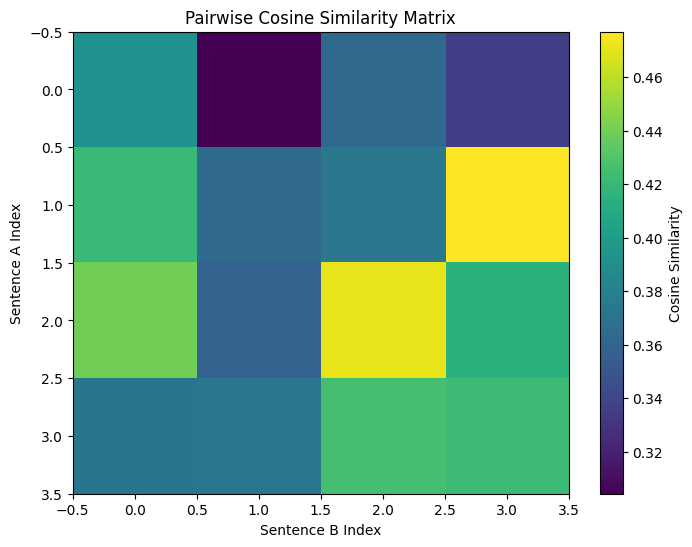

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the similarity (heat) matrix
plt.figure(figsize=(8, 6))
plt.imshow(pairwise_view.similarity_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Cosine Similarity")
plt.title("Pairwise Cosine Similarity Matrix")
plt.xlabel("Sentence B Index")
plt.ylabel("Sentence A Index")
plt.show()

In [ ]:
pairwise_view = sdk.pairwise(text_a, text_b, top_k=5)
pairwise_view.topk_dataframe()

In [21]:
print('hello')

hello


# Some more testing with two real text by Tsonkhapa

## ``Praise to Saraswati`` text sample

In [16]:
saraswati_praise_text = """
༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
 
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག
 

ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
 

པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
 

རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
 

སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །
"""

In [17]:
saraswati_praise_text_segmented = sdk.segment_text(saraswati_praise_text)
for segment in saraswati_praise_text_segmented.segments:
    print(segment)


༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།
ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །
མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །
པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །
མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །
ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །
མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །
མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །
ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །
ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །
ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །
དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །


## ``Foundation of all good qualities`` text by Tsonkhapa

In [18]:
foundation_of_all_good_qualities_text = """
༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
 

ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
 

ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། །
ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། །
མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། །
དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
 

ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
 

སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
 

རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
བྱང་ཆུབ་སེམས་མཆོག་འབྱོངས་པར་བྱིན་གྱིས་རློབས། །
 

སེམས་ཙམ་བསྐྱེད་ཀྱང་ཚུལ་ཁྲིམས་རྣམ་གསུམ་ལ། །
གོམས་པ་མེད་ན་བྱང་ཆུབ་མི་འགྲུབ་པར། །
ལེགས་པར་མཐོང་ནས་རྒྱལ་སྲས་སྡོམ་པ་ལ། །
བརྩོན་པ་དྲག་པོས་སློབ་པར་བྱིན་གྱིས་རློབས། །
 

ལོག་པའི་ཡུལ་ལ་གཡེངས་པ་ཞི་བྱེད་ཅིང༌། །
ཡང་དག་དོན་ལ་ཚུལ་བཞིན་དཔྱོད་པ་ཡིས། །
ཞི་གནས་ལྷག་མཐོང་ཟུང་དུ་འབྲེལ་བའི་ལམ། །
མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
 

ཐུན་མོང་ལམ་སྦྱང་སྣོད་དུ་གྱུར་པ་ན། །
ཐེག་པ་ཀུན་གྱི་མཆོག་གྱུར་རྡོ་རྗེ་ཐེག།
སྐལ་བཟང་སྐྱེ་བོའི་འཇུག་ངོགས་དམ་པ་དེར། །
བདེ་བླག་ཉིད་དུ་འཇུག་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །
རྣམ་དག་དམ་ཚིག་སྡོམ་པར་གསུངས་པ་ལ། །
བཅོས་མ་མིན་པའི་ངེས་པ་རྙེད་གྱུར་ནས། །
སྲོག་དང་བསྡོས་ཏེ་སྲུང་བར་བྱིན་གྱིས་རློབས། །
 

དེ་ནས་རྒྱུད་སྡེ་སྙིང་པོ་རིམ་གཉིས་ཀྱི། །
གནད་རྣམས་ཇི་བཞིན་རྟོགས་ནས་བརྩོན་པ་ཡིས། །
ཐུན་བཞིའི་རྣལ་འབྱོར་སྤྱོད་ལས་མི་གཡེལ་བར། །
དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
 

དེ་ལྟར་ལམ་བཟང་སྟོན་པའི་བཤེས་གཉེན་དང༌། །
ཚུལ་བཞིན་སྒྲུབ་པའི་གྲོགས་རྣམས་ཞབས་བརྟན་ཅིང༌། །
ཕྱི་དང་ནང་གི་བར་དུ་གཅོད་པའི་ཚོགས། །
ཉེ་བར་ཞི་བར་བྱིན་གྱིས་བརླབ་ཏུ་གསོལ། །
 

སྐྱེ་བ་ཀུན་ཏུ་ཡང་དག་བླ་མ་དང་། །
འབྲལ་མེད་ཆོས་ཀྱི་དཔལ་ལ་ལོངས་སྤྱོད་ཅིང་། །
ས་དང་ལམ་གྱི་ཡོན་ཏན་རབ་རྫོགས་ནས། །
རྡོ་རྗེ་འཆང་གི་གོ་འཕང་མྱུར་ཐོབ་ཤོག །
 

ཅེས་པ་འདི་ནི་རྗེ་ཙོང་ཁ་པ་བློ་བཟང་གྲགས་པས་མཛད་པའོ། །
"""

In [19]:
foundation_of_all_good_qualities_text_segments = sdk.segment_text(
    foundation_of_all_good_qualities_text
)
foundation_of_all_good_qualities_text_segments.to_dataframe().head()

,segment_index,start,end,segment_text
0,0,0,36,༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
1,1,36,76,ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
2,2,76,111,ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
3,3,111,145,ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
4,4,145,187,གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །


In [20]:
for segment in foundation_of_all_good_qualities_text_segments.segments:
    print(segment)

༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །
ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །
ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །
ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །
གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །
ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །
ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། ། ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །
རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། ། མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །
ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། ། དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །
ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །
ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །
དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །
རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །
སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །
ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །
ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །
དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །
དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །
སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
མར་གྱུར་འགྲོ་བ་ཀུན

In [22]:
detailed_pairwise_view = sdk.pairwise(saraswati_praise_text, foundation_of_all_good_qualities_text, top_k=10)
detailed_pairwise_view.topk_dataframe()

Loading weights: 100%|██████████| 464/464 [00:00<00:00, 1767.15it/s, Materializing param=model.norm.weight]                                


,rank,score,i,j,sentence_a,sentence_b
0,1,0.587507,8,44,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
1,2,0.530747,8,21,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,སྒྲུབ་པ་སྙིང་པོར་བྱེད་པར་བྱིན་གྱིས་རློབས། །
2,3,0.513949,8,29,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,བརྩོན་པ་དྲག་པོས་སློབ་པར་བྱིན་གྱིས་རློབས། །
3,4,0.513827,8,17,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
4,5,0.511090,11,44,མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །,དམ་པའི་གསུང་བཞིན་སྒྲུབ་པར་བྱིན་གྱིས་རློབས། །
5,6,0.510514,8,48,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,ཉེ་བར་ཞི་བར་བྱིན་གྱིས་བརླབ་ཏུ་གསོལ། །
6,7,0.505490,8,33,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
7,8,0.494472,8,37,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,བདེ་བླག་ཉིད་དུ་འཇུག་པར་བྱིན་གྱིས་རློབས། །
8,9,0.491337,8,7,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །
9,10,0.491304,8,25,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,བྱང་ཆུབ་སེམས་མཆོག་འབྱོངས་པར་བྱིན་གྱིས་རློབས། །


In [ ]:
detailed_pairwise_view

PairwiseView(model_id='buddhist-nlp/gemma-2-mitra-e', device='cpu', segments_a=['༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།', 'ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །', 'མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །', 'དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །', 'རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །', 'པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །', 'མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །', 'རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །', 'ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །', 'རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །', 'མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །', 'མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །', 'ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །', 'སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །', 'ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །', 'ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །', 'དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །'], segments_b=['༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །', 'ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །', 'ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །', 'ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །', 'གུས་པ་ཆེན་པོས་བསྟེན

In [24]:
help(detailed_pairwise_view)

Help on PairwiseView in module tibetan_pipeline.sdk object:

class PairwiseView(builtins.object)
 |  PairwiseView(model_id: 'str', device: 'str', segments_a: 'list[str]', segments_b: 'list[str]', similarity_matrix: 'np.ndarray', matches: 'list[PairMatch]') -> None
 |  
 |  Notebook-friendly pairwise similarity outputs.
 |  
 |  Methods defined here:
 |  
 |  __eq__(self, other)
 |      Return self==value.
 |  
 |  __init__(self, model_id: 'str', device: 'str', segments_a: 'list[str]', segments_b: 'list[str]', similarity_matrix: 'np.ndarray', matches: 'list[PairMatch]') -> None
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  __repr__(self)
 |      Return repr(self).
 |  
 |  topk_dataframe(self) -> 'pd.DataFrame'
 |  
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |  
 |  device
 |  
 |  matches
 |  
 |  model_id
 |  
 |  segments_a
 |  
 |  segments_b
 |  
 |  similarity_matrix
 |  
 |  ----

In [30]:
print(len(detailed_pairwise_view.segments_a))
detailed_pairwise_view.segments_a

17


['༄༅། །སྒྲ་དབྱངས་ལྷ་མོ་དབྱངས་ཅན་མ་ལ་བསྟོད་པ།',
 'ཨོཾ་བདེ་ལེགས་སུ་གྱུར་ཅིག ཆུ་འཛིན་དཀར་པོའི་གློག་ཕྲེང་དྲ་བ་ཅན། །',
 'མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །',
 'དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །',
 'རིང་ནས་བརྩེ་བའི་ལྷ་མོ་ད་ཚུར་བྱོན། །',
 'པད་མའི་བཞིན་ལ་གཡོ་ལྡན་བུང་བའི་མིག །',
 'མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །',
 'རོལ་སྒེག་གར་གྱིས་འགྱིང་བའི་དབྱངས་ཅན་མ། །',
 'ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །',
 'རོལ་རྩེད་གར་གྱི་ཉམས་ལྡན་རི་དྭགས་མིག །',
 'མིག་གིས་བལྟ་བས་མི་ངོམ་ཡིད་འཕྲོག་མ། །',
 'མ་ལྟར་བརྩེ་བ་ཁྱེད་ཀྱིས་བདག་གི་ངག །',
 'ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །',
 'སྟོན་ཟླ་རྒྱས་པའི་དཔལ་ལས་ལྷག་པར་མཛེས། །',
 'ཚངས་དབྱངས་སྙན་པའི་གདངས་ཀྱང་ཟིལ་གྱིས་གནོན། །',
 'ཟབ་ཡངས་རྒྱ་མཚོའི་འཇིང་ལྟར་དཔག་དཀའ་བ། །',
 'དབྱངས་ཅན་ལྷ་མོའི་སྐུ་གསུང་ཐུགས་ལ་འདུད། །']

In [29]:
print(len(detailed_pairwise_view.segments_b))
detailed_pairwise_view.segments_b


51


['༄༅། །ཡོན་ཏན་གཞིར་གྱུར་མ་བཞུགས་སོ། །',
 'ཡོན་ཏན་ཀུན་གྱི་གཞིར་གྱུར་དྲིན་ཅན་རྗེ། །',
 'ཚུལ་བཞིན་བསྟེན་པ་ལམ་གྱི་རྩ་བ་རུ། །',
 'ལེགས་པར་མཐོང་ནས་འབད་པ་དུ་མ་ཡིས། །',
 'གུས་པ་ཆེན་པོས་བསྟེན་པར་བྱིན་གྱིས་རློབས། །',
 'ལན་ཅིག་རྙེད་པའི་དལ་བའི་རྟེན་བཟང་འདི། །',
 'ཤིན་ཏུ་རྙེད་དཀའ་དོན་ཆེ་ཤེས་གྱུར་ནས། ། ཉིན་མཚན་ཀུན་ཏུ་སྙིང་པོ་ལེན་པའི་བློ། །',
 'རྒྱུན་ཆད་མེད་པར་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །',
 'ལུས་སྲོག་གཡོ་བ་ཆུ་ཡི་ཆུ་བུར་བཞིན། ། མྱུར་དུ་འཇིག་པའི་འཆི་བ་དྲན་པ་དང༌། །',
 'ཤི་བའི་རྗེས་སུ་ལུས་དང་གྲིབ་མ་བཞིན། ། དཀར་ནག་ལས་འབྲས་ཕྱི་བཞིན་འབྲང་བ་ལ། །',
 'ངེས་པ་བརྟན་པོ་རྙེད་ནས་ཉེས་པའི་ཚོགས། །',
 'ཕྲ་ཞིང་ཕྲ་བ་རྣམས་ཀྱང་སྤོང་བ་དང༌། །',
 'དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །',
 'རྟག་ཏུ་བག་དང་ལྡན་པར་བྱིན་གྱིས་རློབས། །',
 'སྤྱད་པས་མི་ངོམས་སྡུག་བསྔལ་ཀུན་གྱི་སྒོ། །',
 'ཡིད་བརྟན་མི་རུང་སྲིད་པའི་ཕུན་ཚོགས་ཀྱི། །',
 'ཉེས་དམིགས་རིག་ནས་ཐར་བའི་བདེ་བ་ལ། །',
 'དོན་གཉེར་ཆེན་པོ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །',
 'རྣམ་དག་བསམ་པ་དེ་ཡིས་དྲངས་པ་ཡི། །',
 'དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །',
 'བསྟན་པའི་རྩ་བ་སོ་སོར་ཐར་བ་ལ། །',
 'སྒྲུབ་པ་སྙིང་པ

In [28]:
detailed_pairwise_view.similarity_matrix.shape

(17, 51)

In [32]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


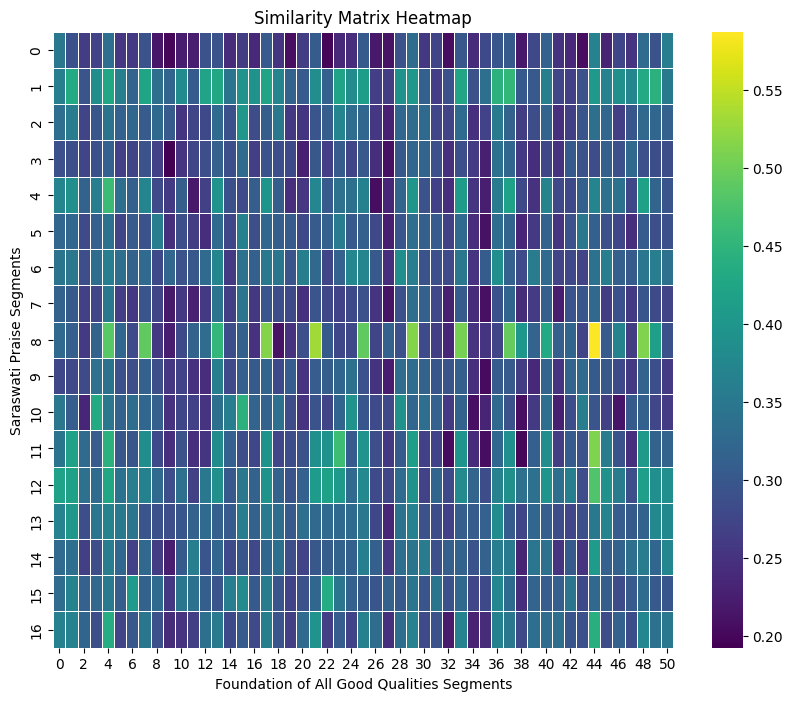

In [33]:
# plot the similarity matrix heatplot 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    detailed_pairwise_view.similarity_matrix, 
    cmap="viridis", 
    linewidths=0.5, 
    annot=False
)
plt.title("Similarity Matrix Heatmap")
plt.xlabel("Foundation of All Good Qualities Segments")
plt.ylabel("Saraswati Praise Segments")
plt.show()

## let's use openAI embedder to check

In [34]:
!pip install openai

  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.3 MB/s  0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached pydantic-2.12.5-py3-none-any.whl (463 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.6 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [openai]2m7/8 [openai]


In [36]:
print(os.getenv("OPENAI_API_KEY"))

None


In [37]:
OPENAI_API_KEY="sk-...redacted..."

In [38]:
import openai

# Prepare your OpenAI API Key (replace with your actual key or ensure environment variable is set)
import os
openai.api_key = OPENAI_API_KEY # Or set explicitly

# Example: Choose the modern OpenAI embedding model name
embedding_model = "text-embedding-ada-002"

# Combine both segment sets for demonstration
all_segments = detailed_pairwise_view.segments_a + detailed_pairwise_view.segments_b

# Use the new OpenAI v1 API for embeddings (openai>=1.0.0)
# See: https://github.com/openai/openai-python#migrating-from-v0-to-v1 for migration details

client = openai.OpenAI(api_key=openai.api_key)
response = client.embeddings.create(
    model=embedding_model,
    input=all_segments,
)

embeddings = [item.embedding for item in response.data]

# Optionally split back into segments_a and segments_b embeddings
embeddings_a = embeddings[:len(detailed_pairwise_view.segments_a)]
embeddings_b = embeddings[len(detailed_pairwise_view.segments_a):]

print(f"Number of embeddings from OpenAI: {len(embeddings)}")
print(f"Shape of each embedding: {len(embeddings[0])} dimensions")

Number of embeddings from OpenAI: 68
Shape of each embedding: 1536 dimensions


In [46]:
import numpy as np
import pandas as pd

def cosine_similarity_matrix(vecs_a: list[list[float]], vecs_b: list[list[float]]) -> np.ndarray:
    """
    Compute the cosine similarity matrix between two lists of embedding vectors.

    Args:
        vecs_a: List of N vectors (A).
        vecs_b: List of M vectors (B).

    Returns:
        N x M matrix of cosine similarities.
    """
    a = np.array(vecs_a)  # shape (N, D)
    b = np.array(vecs_b)  # shape (M, D)
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)
    similarity = np.dot(a_norm, b_norm.T)  # shape (N, M)
    return similarity

def top_k_similarity_pairs(similarity_matrix: np.ndarray, k: int) -> list[tuple[int, int, float]]:
    """
    Return the top k pairs (indices from A, indices from B, and similarity value)
    with the highest cosine similarities in the matrix.

    Args:
        similarity_matrix: np.ndarray of shape (N, M)
        k: number of top pairs to return

    Returns:
        List of tuples: (index_a, index_b, similarity_value)
    """
    # Flatten and get indices
    flat_indices = np.argpartition(-similarity_matrix.ravel(), k-1)[:k]
    row_indices, col_indices = np.unravel_index(flat_indices, similarity_matrix.shape)
    similarities = similarity_matrix[row_indices, col_indices]
    # Sort descending
    sorted_indices = np.argsort(-similarities)
    top_pairs = [(int(row_indices[i]), int(col_indices[i]), float(similarities[i])) for i in sorted_indices]
    return top_pairs

similarity_matrix = cosine_similarity_matrix(embeddings_a, embeddings_b)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print("First 3 similarity scores (row 0):", similarity_matrix[0][:3])

# Get top k most similar pairs
top_k = 10
top_pairs = top_k_similarity_pairs(similarity_matrix, top_k)

print(f"Top {top_k} most similar pairs (A index, B index, similarity):")
for idx_a, idx_b, sim in top_pairs:
    sent_a = detailed_pairwise_view.segments_a[idx_a]
    sent_b = detailed_pairwise_view.segments_b[idx_b]
    print(f"A[{idx_a}] <--> B[{idx_b}] : {sim:.4f}")
    print(f"    A: {sent_a}")
    print(f"    B: {sent_b}")

# Create a DataFrame for view, similar to above DataFrame patterns
top_pairs_data = []
for idx_a, idx_b, sim in top_pairs:
    sent_a = detailed_pairwise_view.segments_a[idx_a]
    sent_b = detailed_pairwise_view.segments_b[idx_b]
    top_pairs_data.append({
        "A_index": idx_a,
        "B_index": idx_b,
        "A_sentence": sent_a,
        "B_sentence": sent_b,
        "similarity": sim
    })

top_pairs_df = pd.DataFrame(top_pairs_data)
display(top_pairs_df)

Similarity matrix shape: (17, 51)
First 3 similarity scores (row 0): [0.9557442  0.91223094 0.90304207]
Top 10 most similar pairs (A index, B index, similarity):
A[6] <--> B[24] : 0.9761
    A: མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
    B: མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
A[8] <--> B[38] : 0.9733
    A: ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །
    B: དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །
A[3] <--> B[19] : 0.9726
    A: དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །
    B: དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །
A[2] <--> B[24] : 0.9705
    A: མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
    B: མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །
A[6] <--> B[23] : 0.9704
    A: མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །
    B: མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
A[2] <--> B[23] : 0.9701
    A: མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །
    B: མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །
A[12] <--> B[22] : 0.9693
    A: ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །
    B: རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །
A[8] <--> B[12] : 0.9687
  

,A_index,B_index,A_sentence,B_sentence,similarity
0,6,24,མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །,མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །,0.976110
1,8,38,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,དེ་ཚེ་དངོས་གྲུབ་རྣམ་གཉིས་སྒྲུབ་པའི་གཞི། །,0.973259
2,3,19,དྲི་ཟའི་ན་ཆུང་དབུས་ན་འཇོ་སྒེག་མཁན། །,དྲན་དང་ཤེས་བཞིན་བག་ཡོད་ཆེན་པོ་ཡིས། །,0.972593
3,2,24,མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །,མཐོང་ནས་འགྲོ་བ་སྒྲོལ་བའི་ཁུར་འཁྱེར་བའི། །,0.970531
4,6,23,མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །,མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །,0.970439
5,2,23,མཁའ་ཡི་མཛེས་བྱེད་འདྲ་བའི་ཡིད་འཕྲོག་མ། །,མར་གྱུར་འགྲོ་བ་ཀུན་ཀྱང་དེ་འདྲ་བར། །,0.970069
6,12,22,ངག་དབང་ལྷ་མོ་ཉིད་དང་མཚུངས་པར་མཛོད། །,རང་ཉིད་སྲིད་མཚོར་ལྷུང་བ་ཇི་བཞིན་དུ། །,0.969260
7,8,12,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,དགེ་ཚོགས་མཐའ་དག་སྒྲུབ་པར་བྱེད་པ་ལ། །,0.968694
8,6,33,མཐོན་མཐིང་རལ་པའི་རྩེ་ན་འོད་དཀར་ཅན། །,མྱུར་དུ་རྒྱུད་ལ་སྐྱེ་བར་བྱིན་གྱིས་རློབས། །,0.967168
9,8,47,ད་དུང་བདག་ལ་ངག་གི་དངོས་གྲུབ་སྩོལ། །,ཕྱི་དང་ནང་གི་བར་དུ་གཅོད་པའི་ཚོགས། །,0.966851


In [44]:
top_pairs

[(6, 24, 0.9761100068741134),
 (8, 38, 0.973258787206024),
 (3, 19, 0.9725928026383891),
 (2, 24, 0.9705310217893277),
 (6, 23, 0.9704387011701956),
 (2, 23, 0.970069420911669),
 (12, 22, 0.9692595934010241),
 (8, 12, 0.968693794280597),
 (6, 33, 0.967168260841916),
 (8, 47, 0.9668505032393176)]